In [1]:
import os
import cv2
import argparse
import numpy as np
import time
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis, spearmanr, kendalltau, wasserstein_distance
from skimage.metrics import structural_similarity as ssim
from math import log2
import seaborn as sns
from scipy.stats import linregress
from FreeAeonFractal.FAImageLACGPU import CFAImageLACGPU as CFAImageLAC
from FreeAeonFractal.FAImageFDGPU import CFAImageFDGPU as CFAImageFD
from FreeAeonFractal.FAImageMFSGPU import CFAImageMFSGPU as CFAImageMFS
from ImageConstruct import CImageUtils,CImageAlpha,CImageMFS
from ImageSimilarity import CImageSimilarity
from ImageDecompose import CImageDecompose
np.set_printoptions(suppress=True, precision=8)

In [2]:
real_mean = CImageUtils.read_image("./images/real-mean.exr")
fake_mean = CImageUtils.read_image("./images/fake-mean.exr")
real_mean = CImageUtils.resize(real_mean)
fake_mean = CImageUtils.resize(fake_mean)

real = CImageMFS(real_mean,q_count=64)
fake = CImageMFS(fake_mean,q_count=64)

real.parse()
fake.parse()

In [9]:
real.get_mfs_images()['gray'].shape

(64, 64, 3)

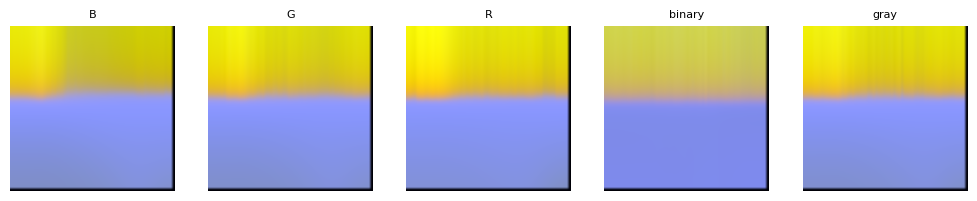

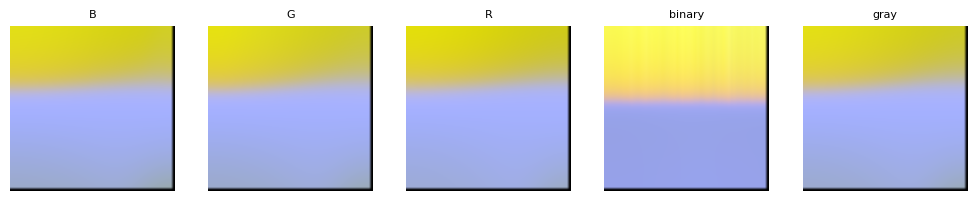

In [10]:
CImageUtils.display(real.get_mfs_images((256,256)))
CImageUtils.display(fake.get_mfs_images((256,256)))

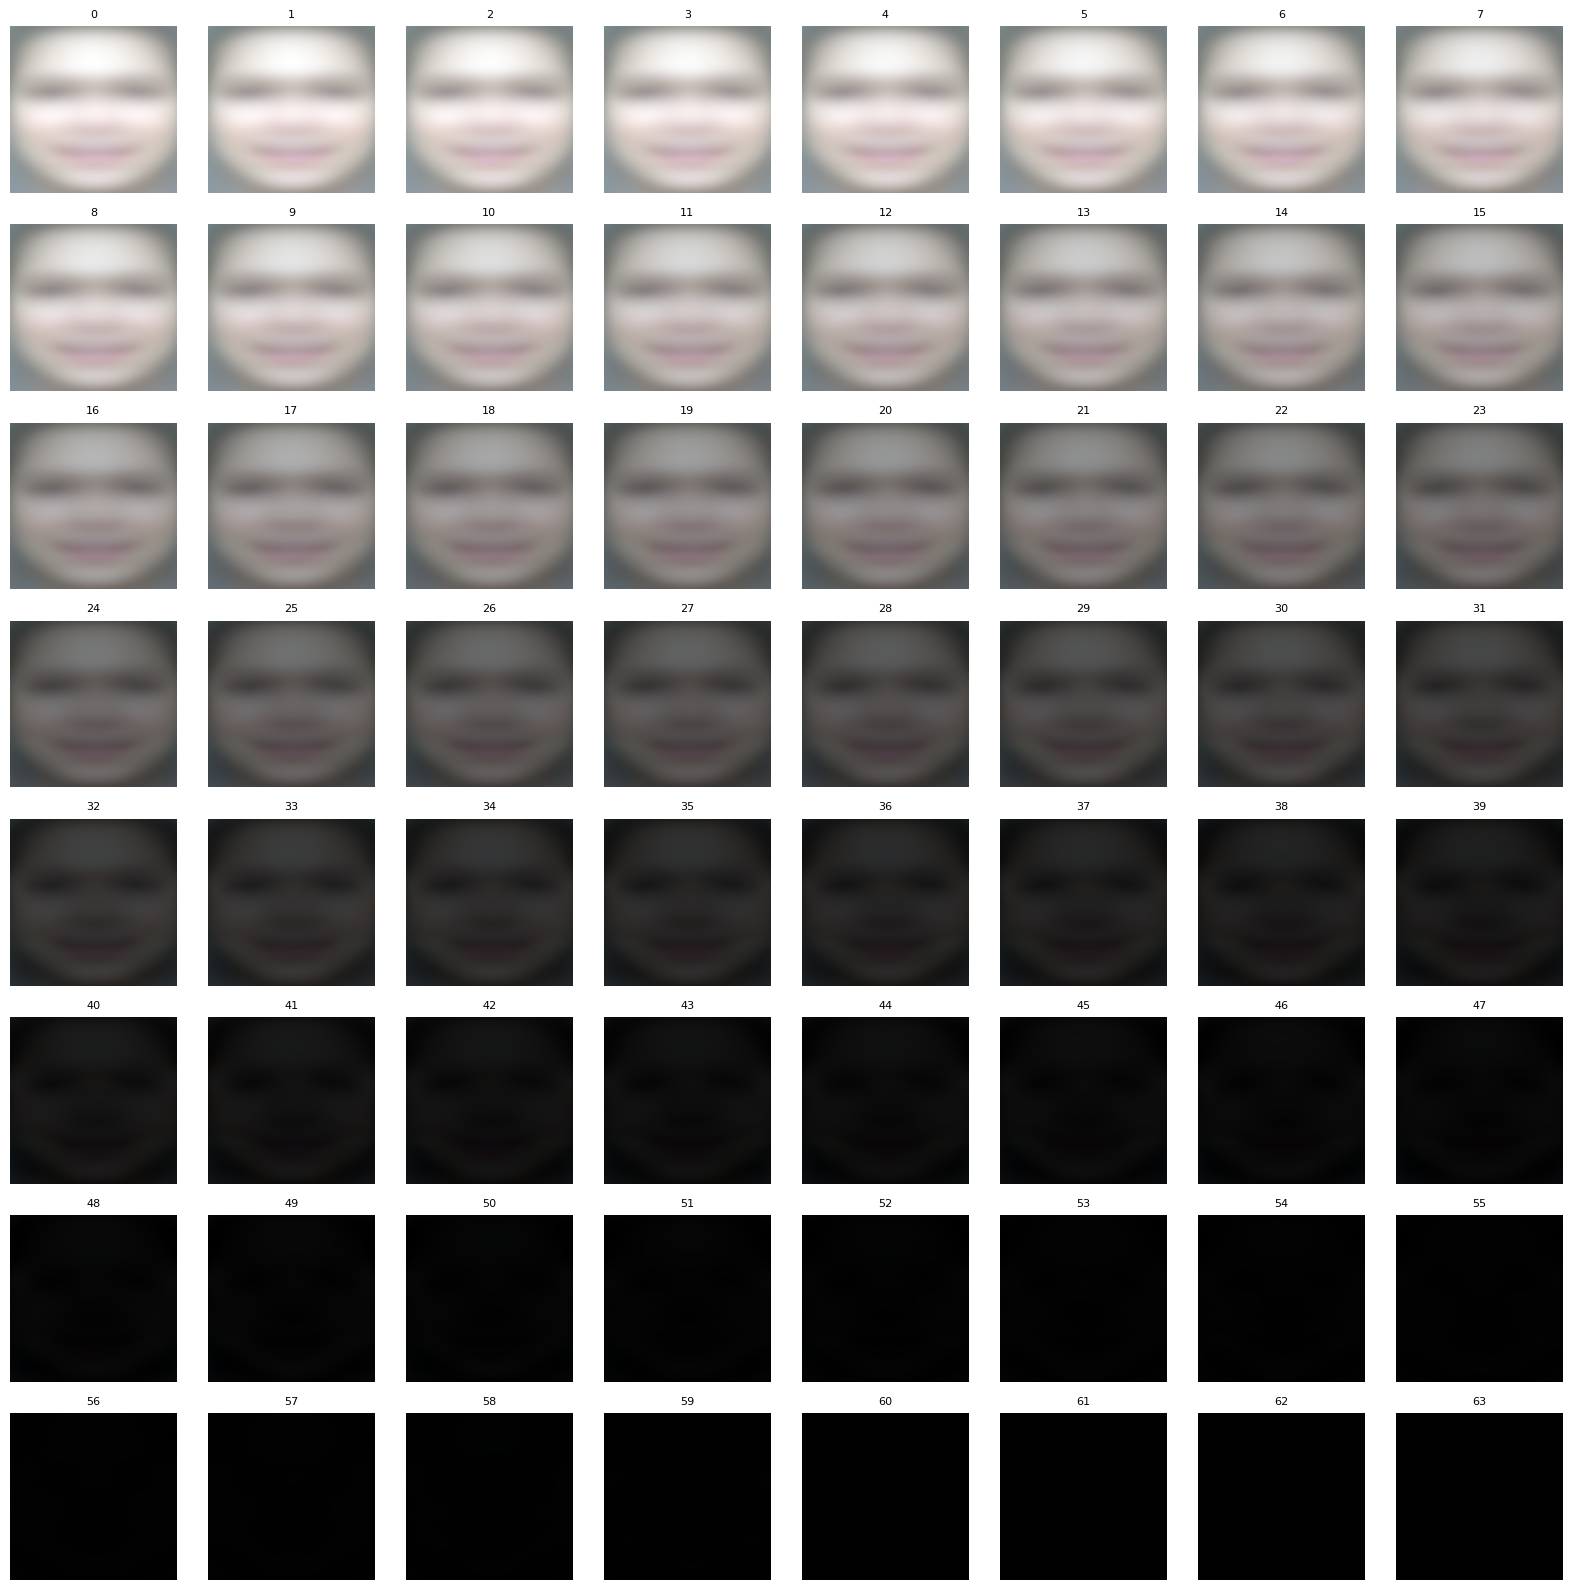

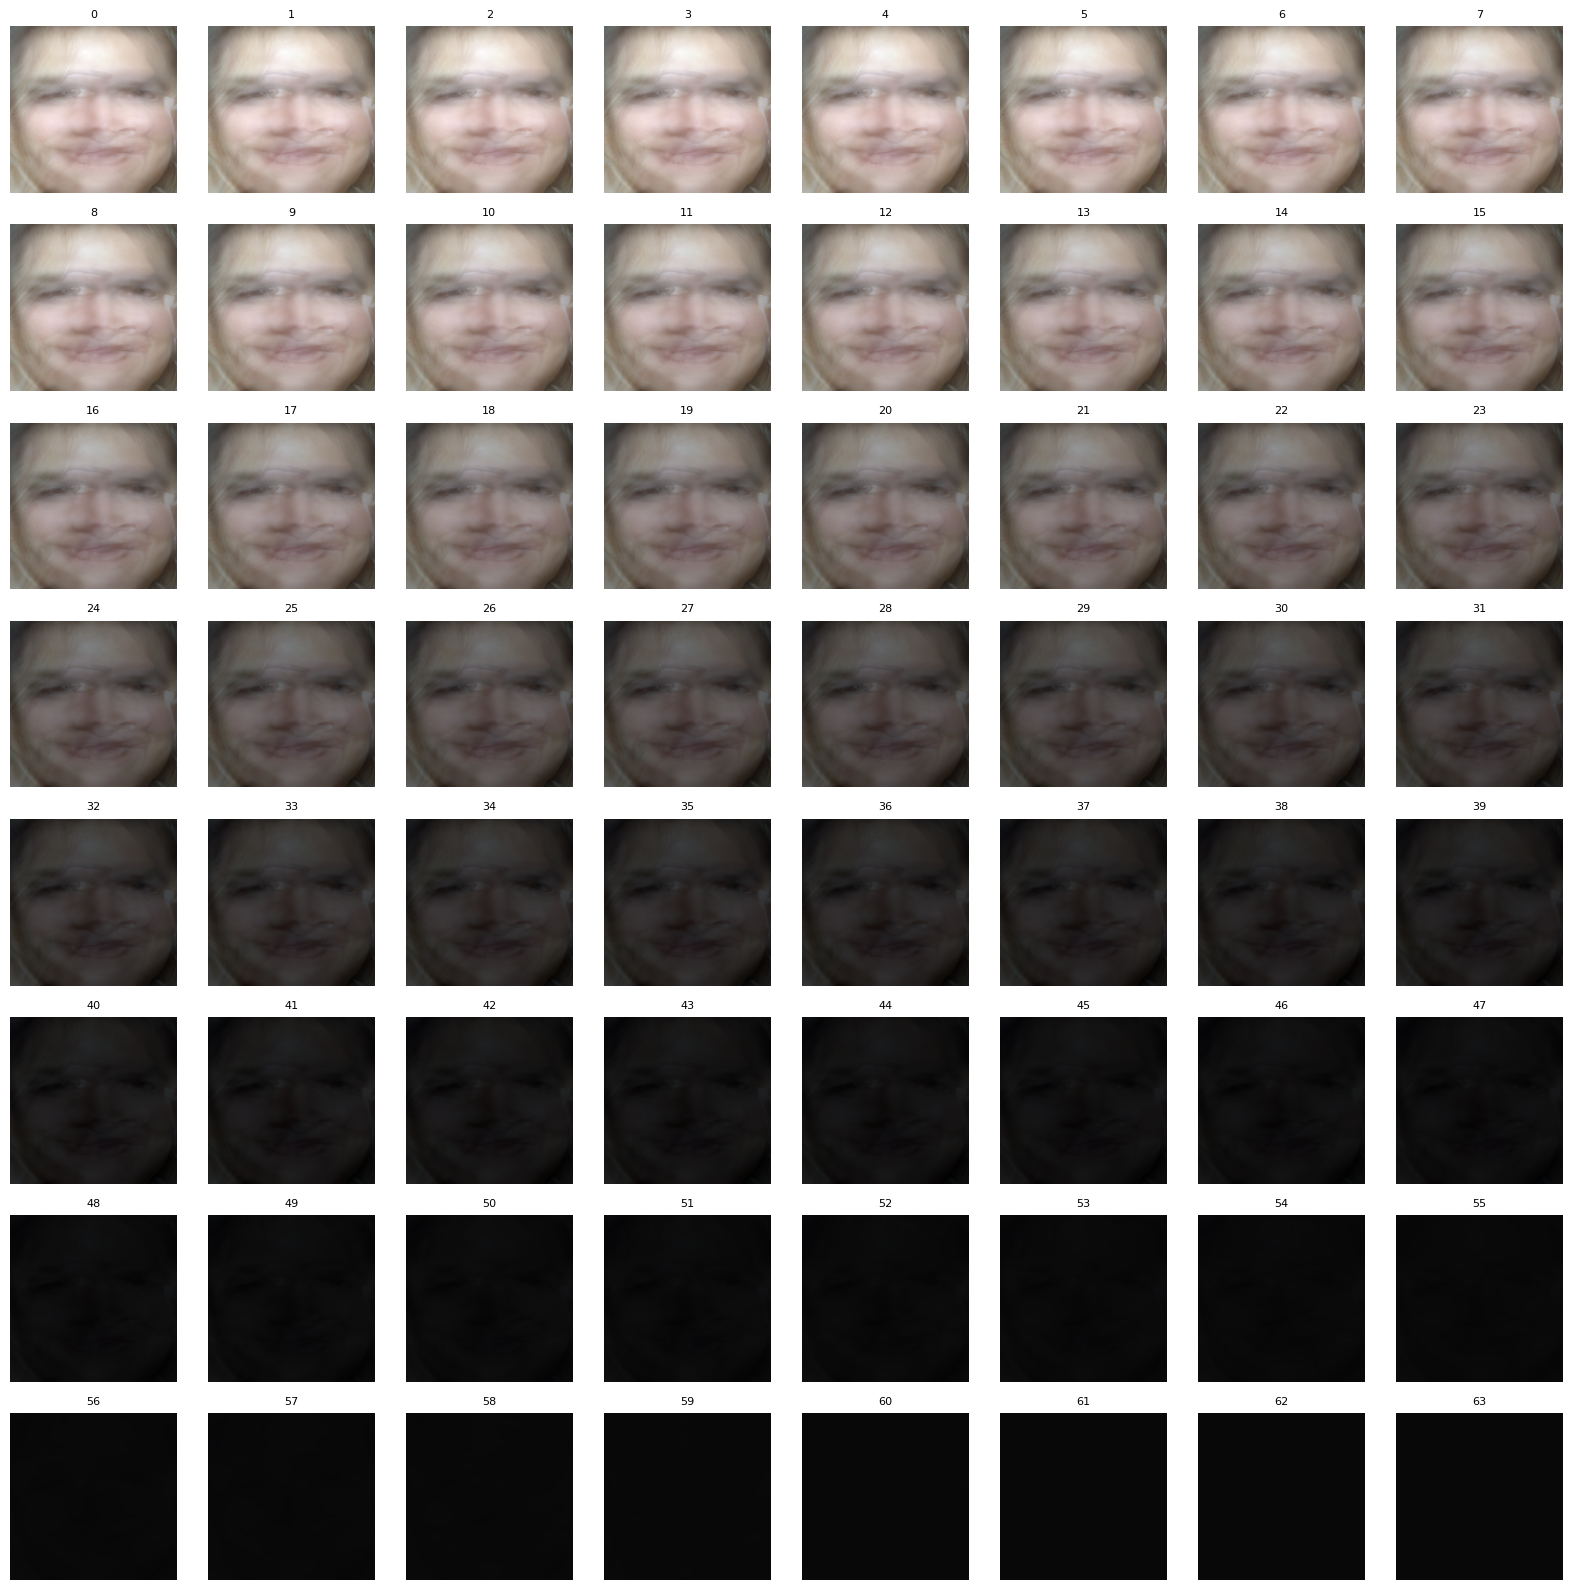

In [11]:
CImageUtils.display(real.get_svd())
CImageUtils.display(fake.get_svd())

In [12]:
df_real = real.get_mfs()
df_real['label'] = 'real'
df_fake = fake.get_mfs()
df_fake['label'] = 'fake'
df_data = pd.concat([df_real,df_fake],ignore_index=True).reset_index(drop=True)

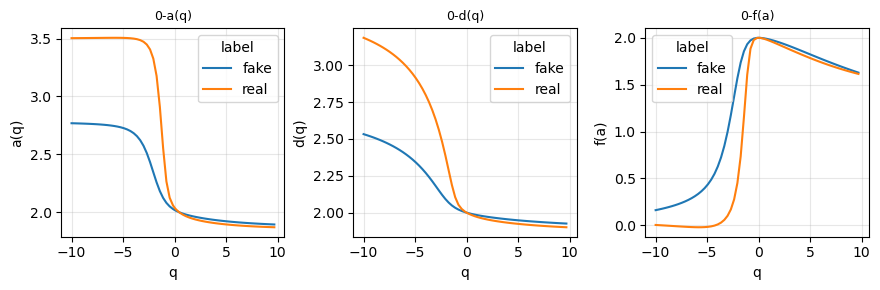

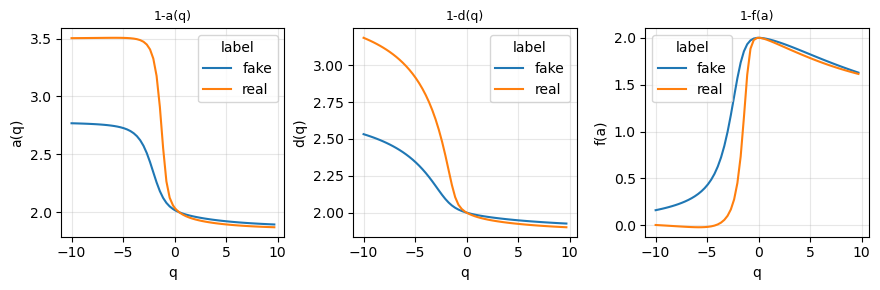

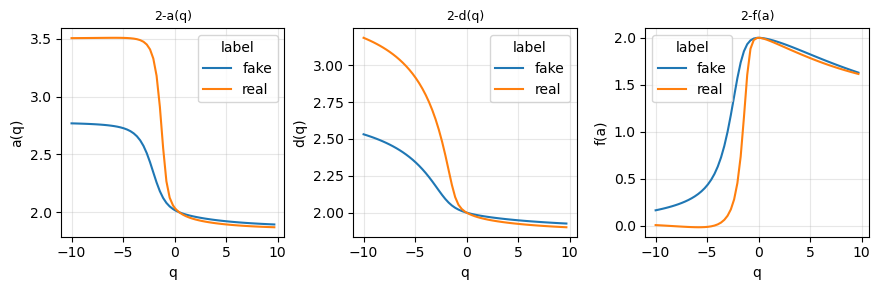

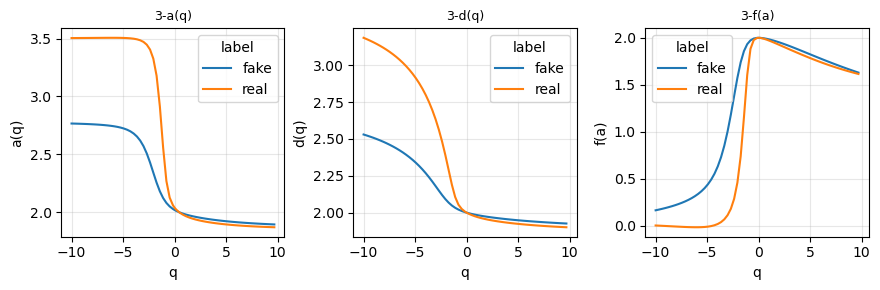

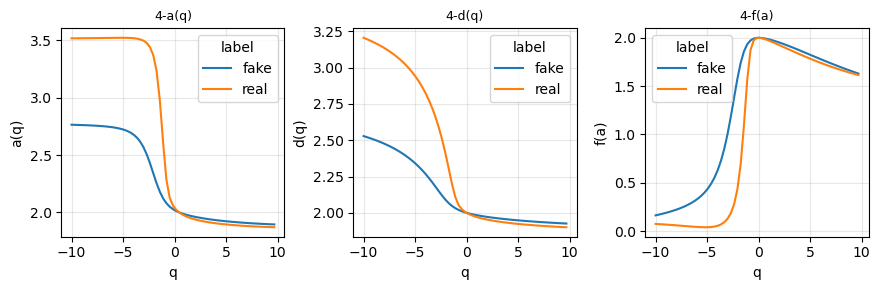

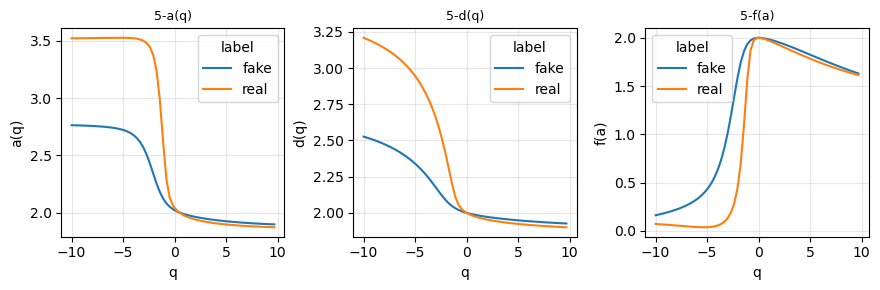

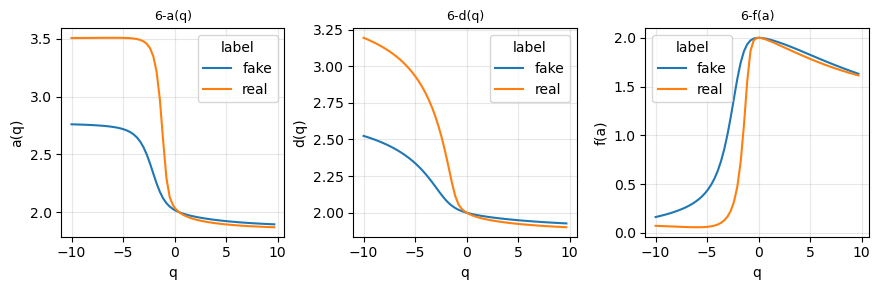

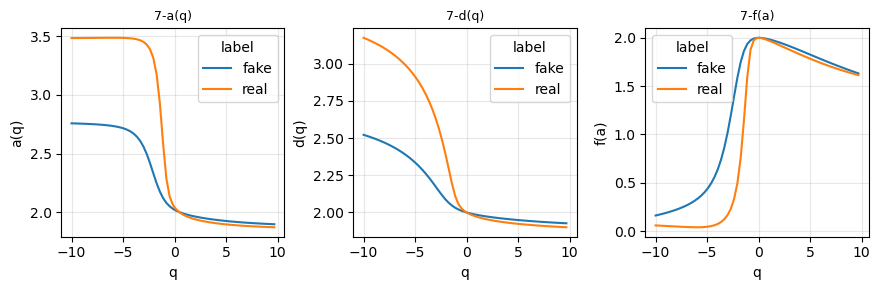

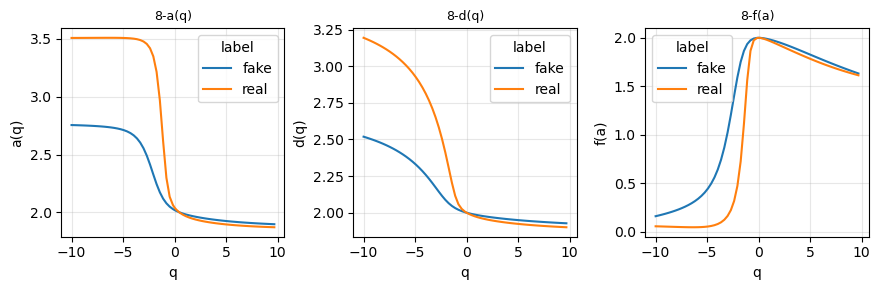

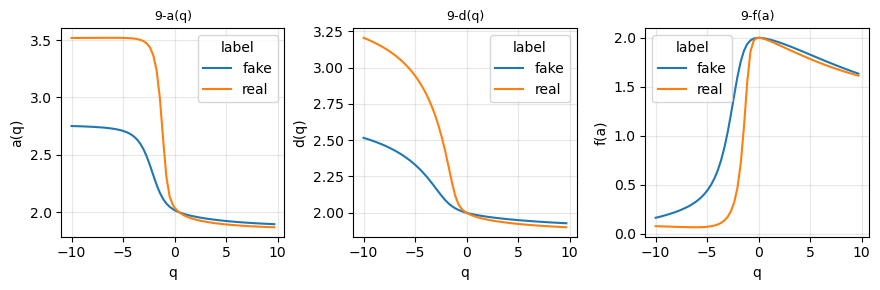

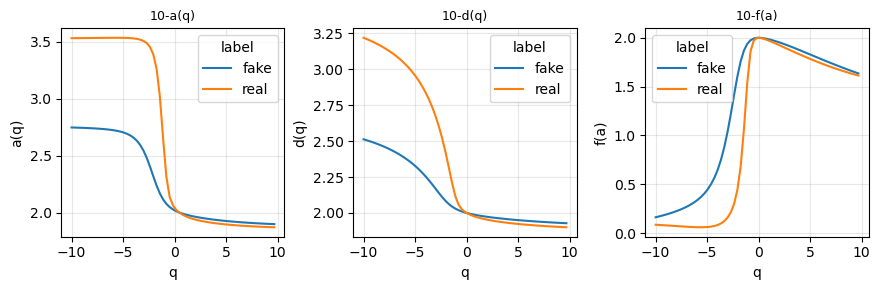

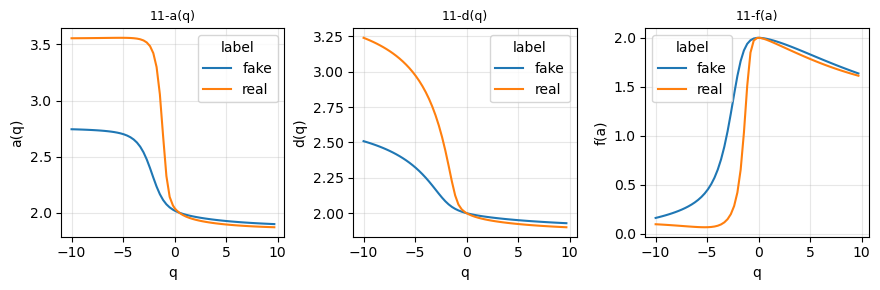

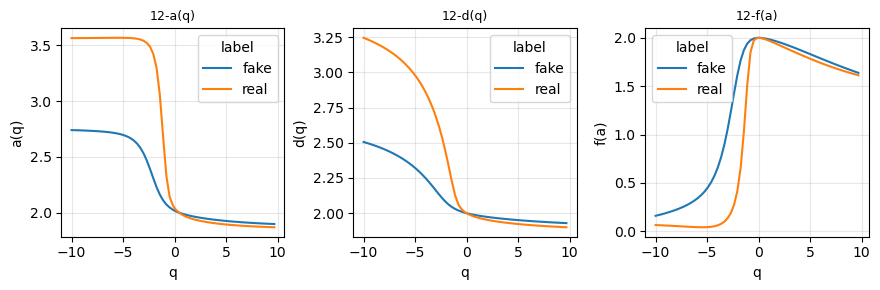

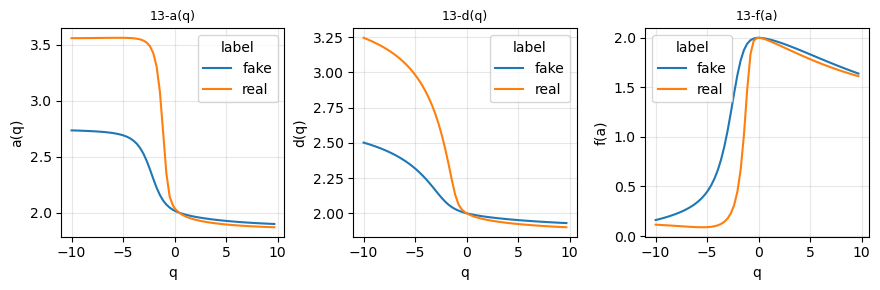

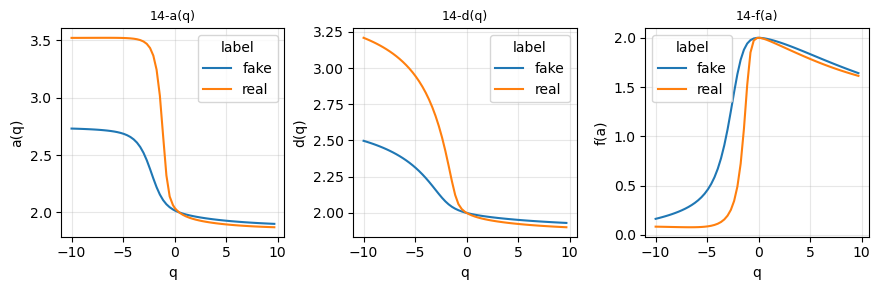

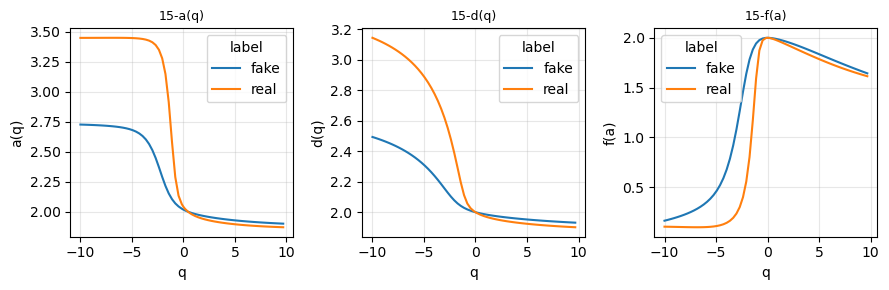

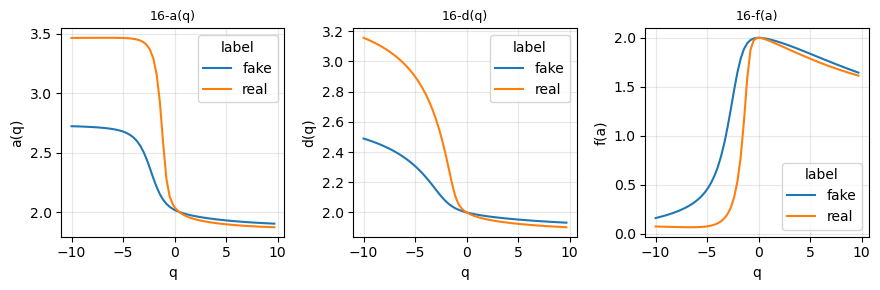

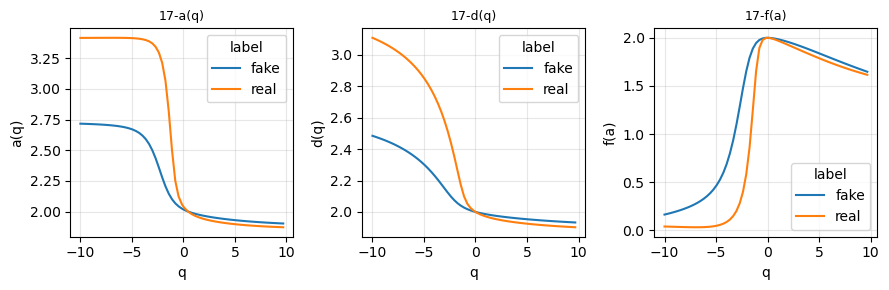

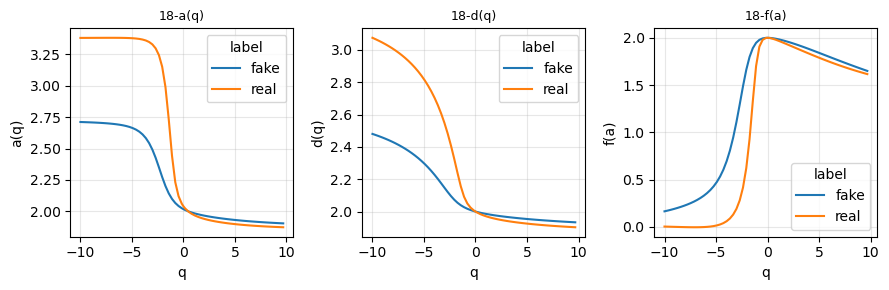

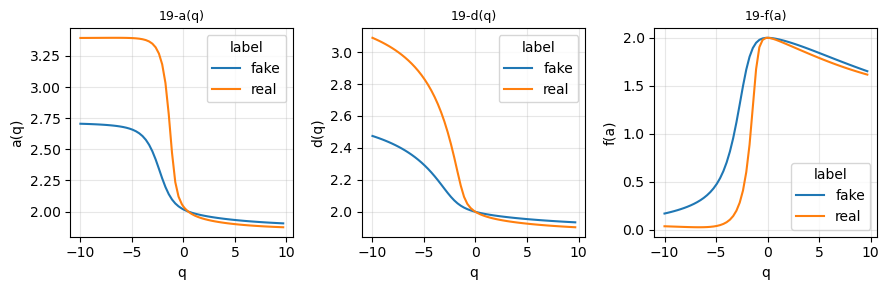

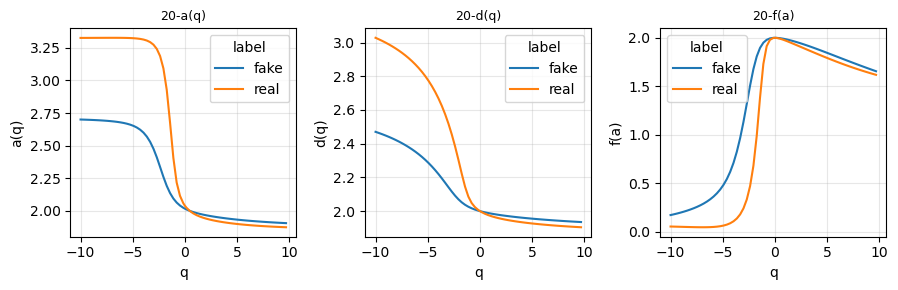

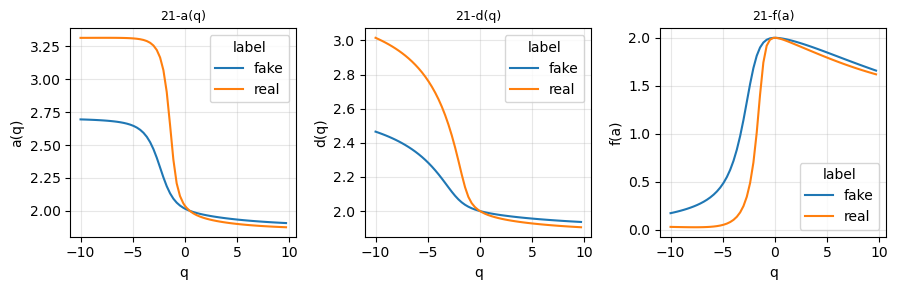

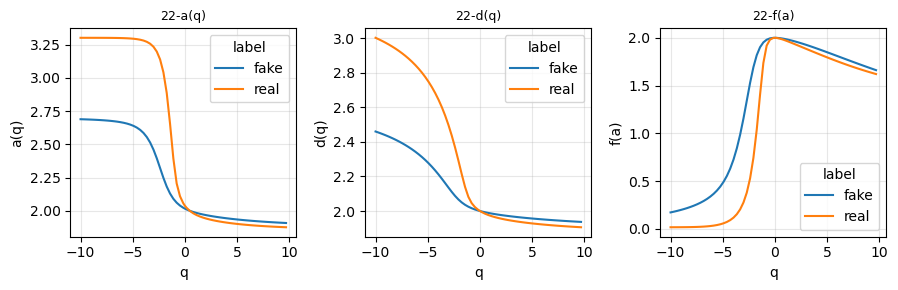

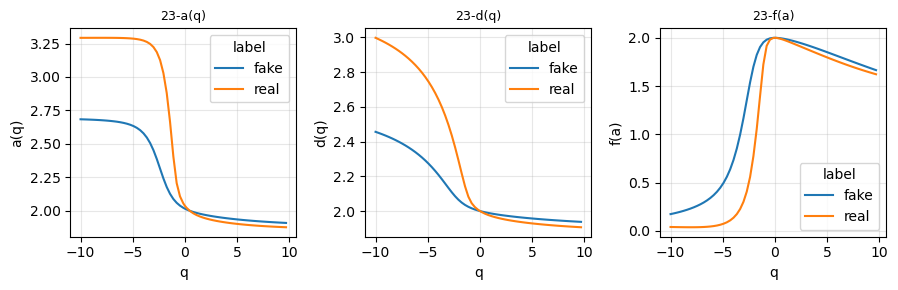

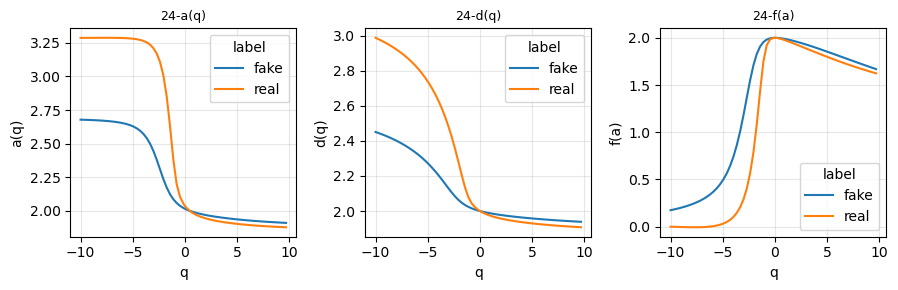

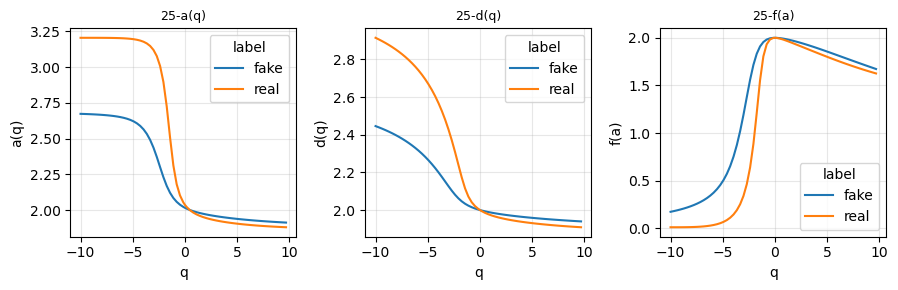

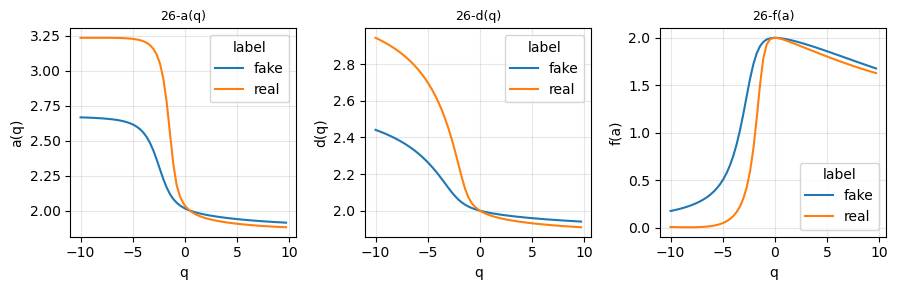

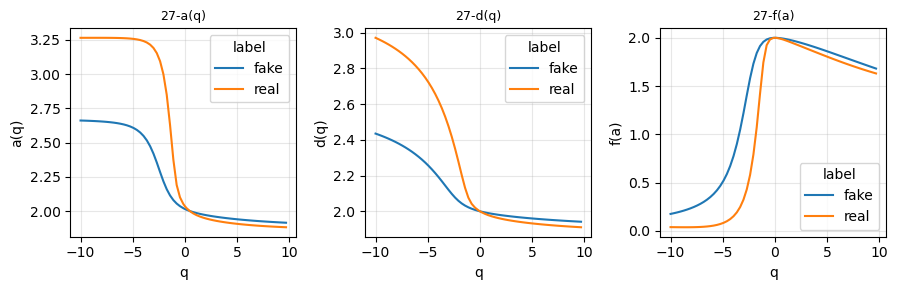

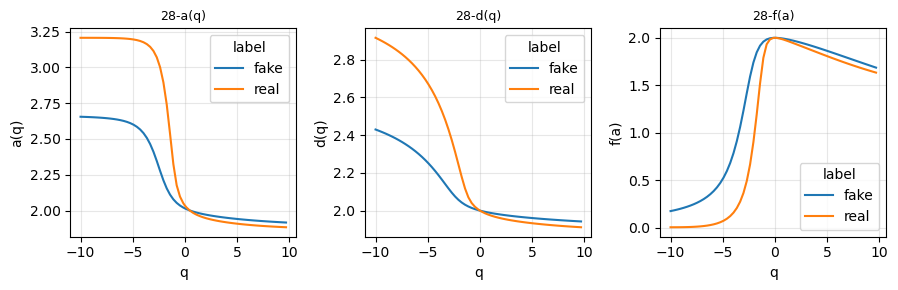

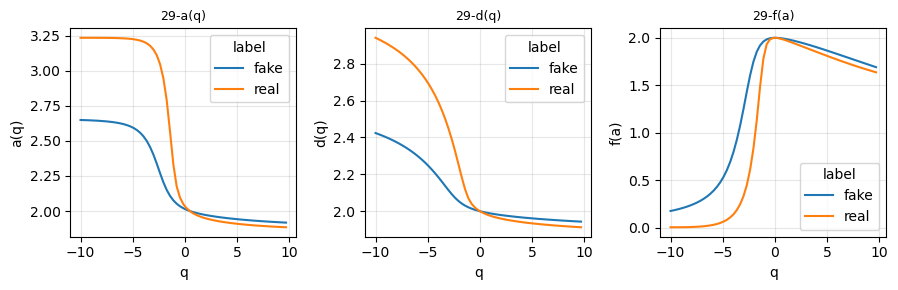

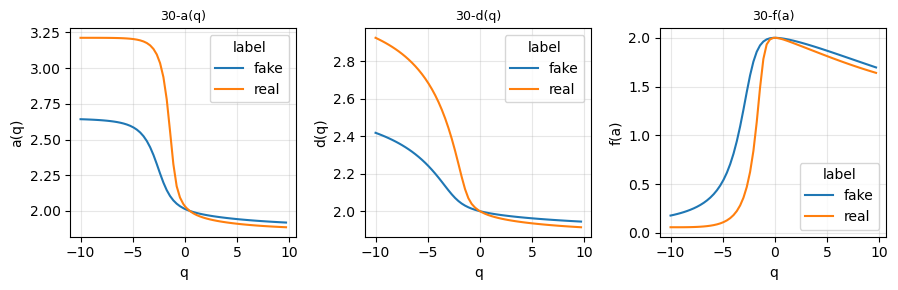

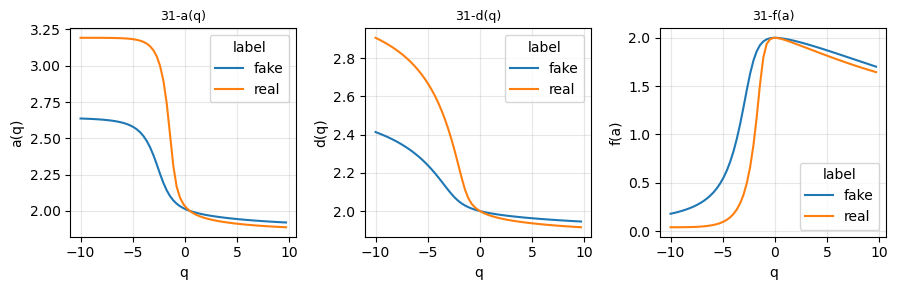

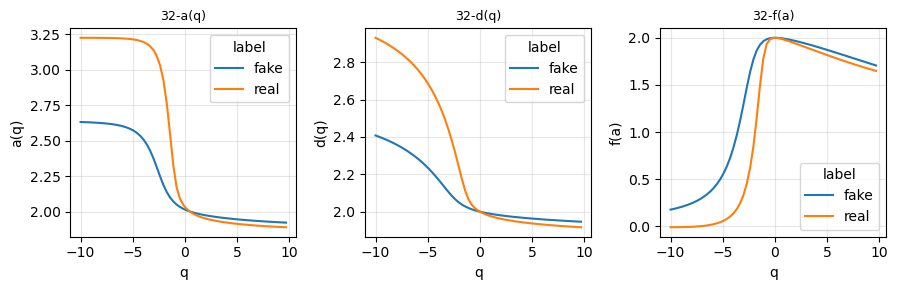

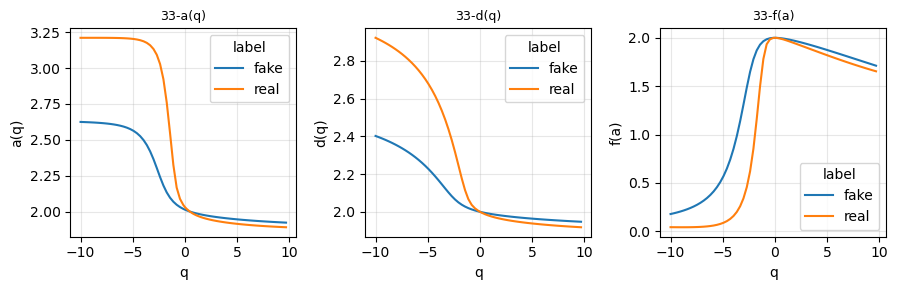

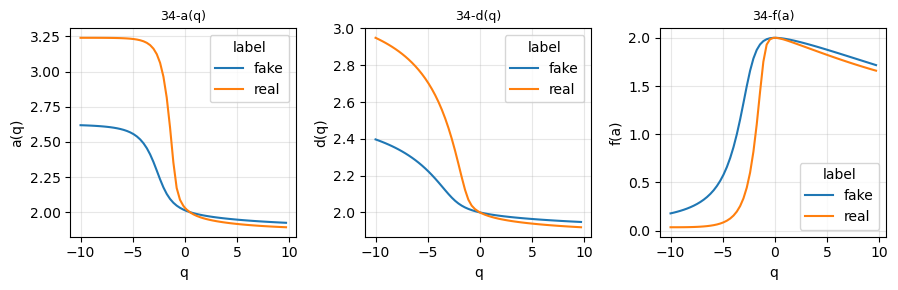

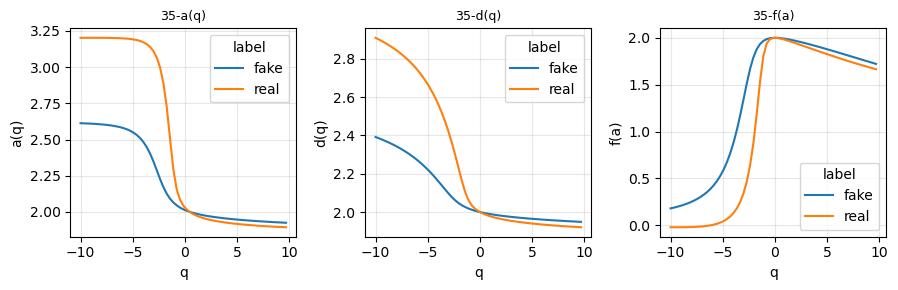

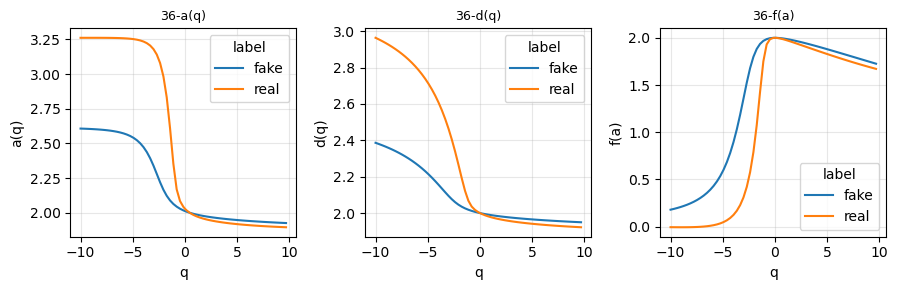

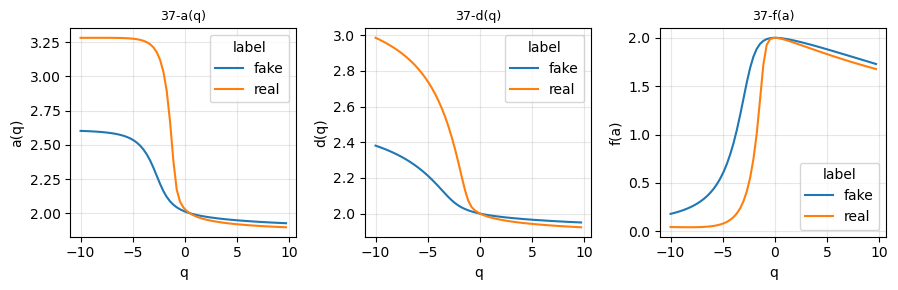

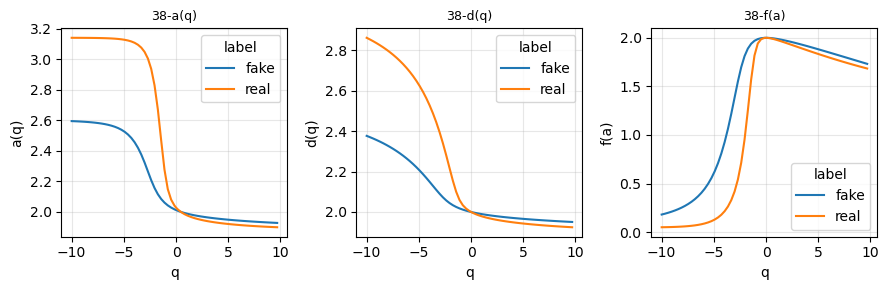

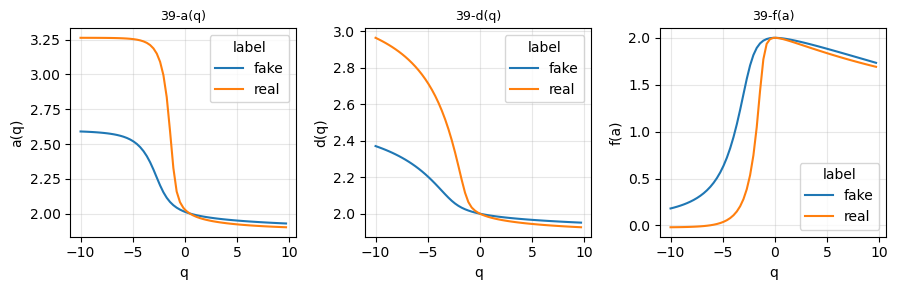

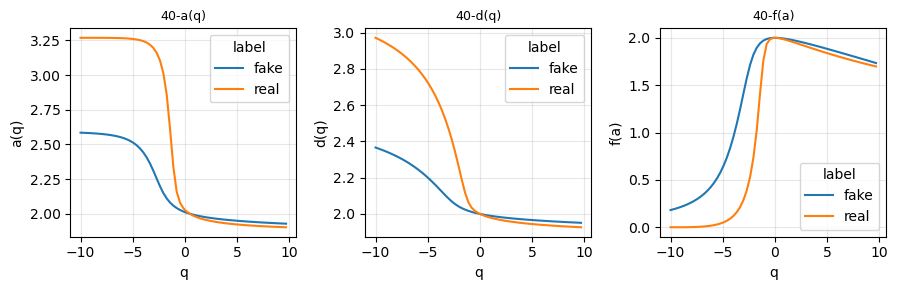

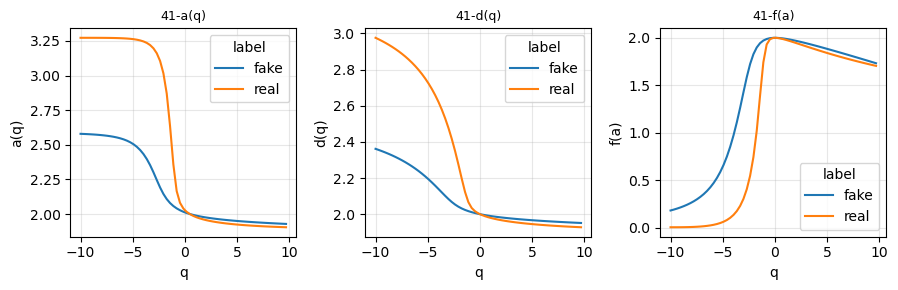

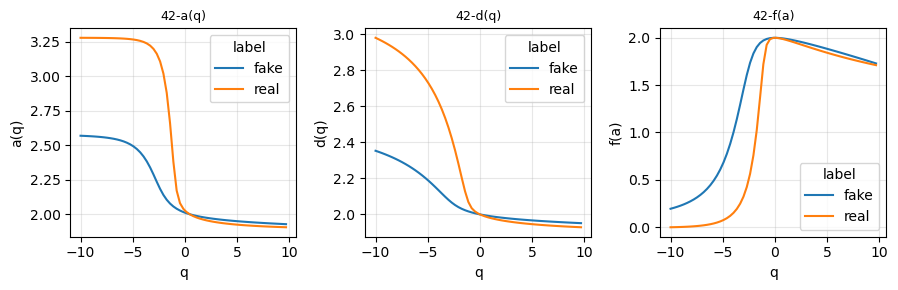

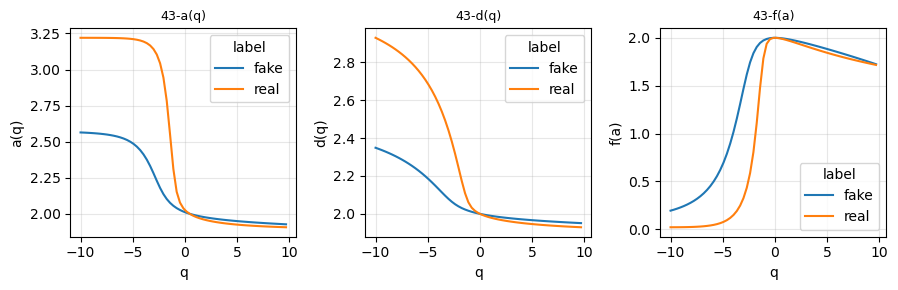

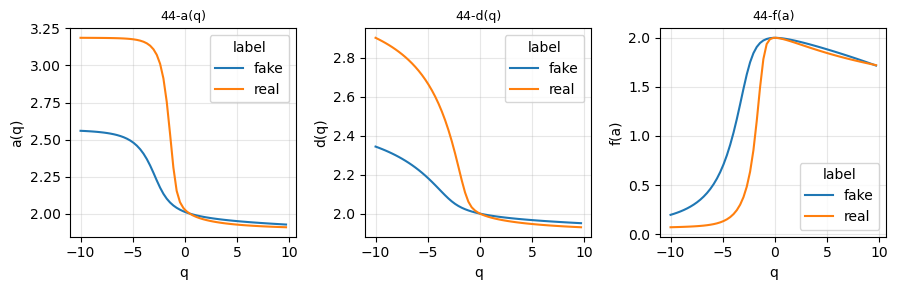

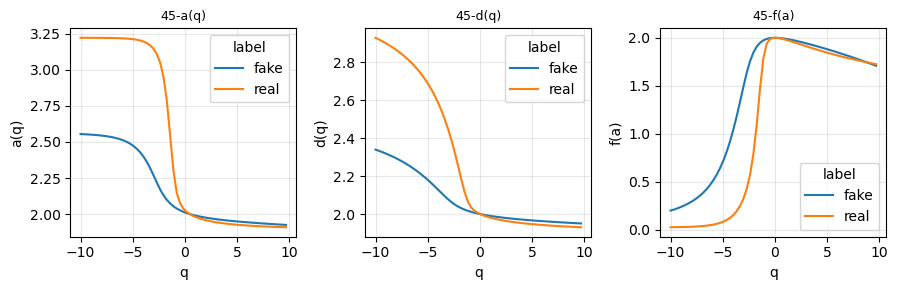

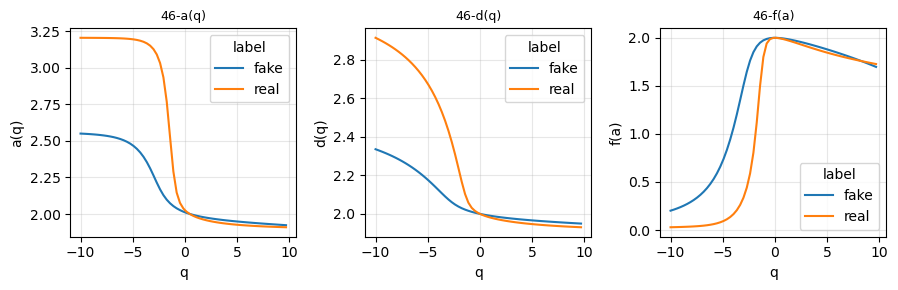

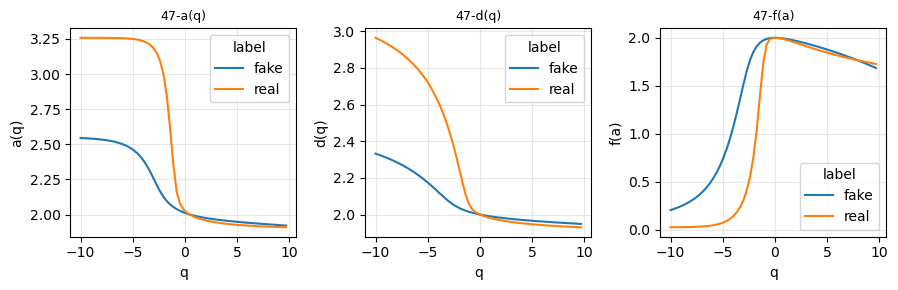

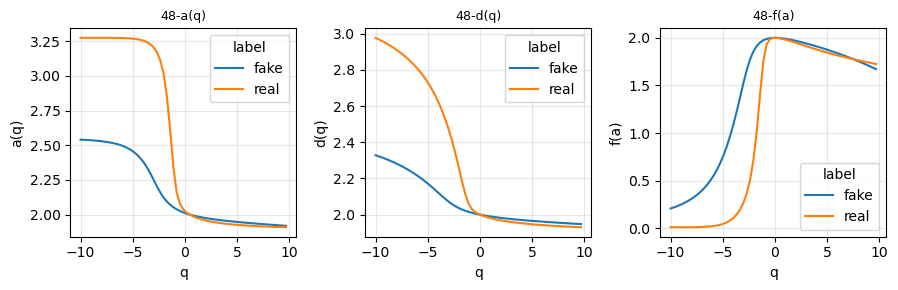

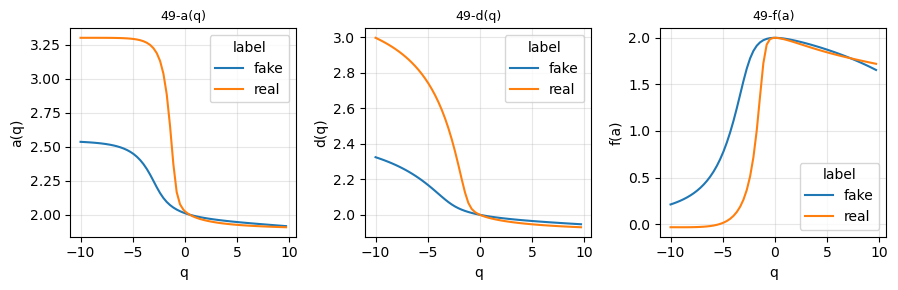

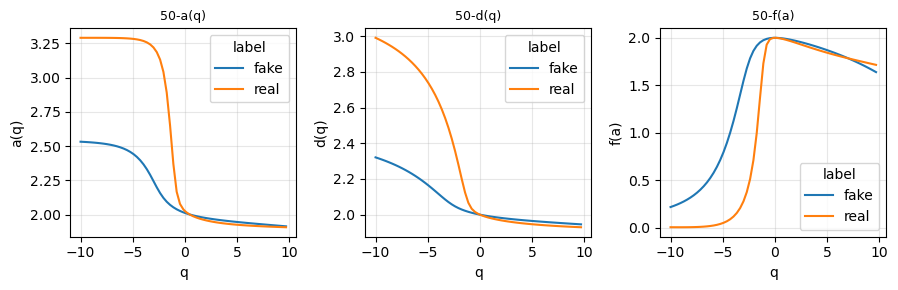

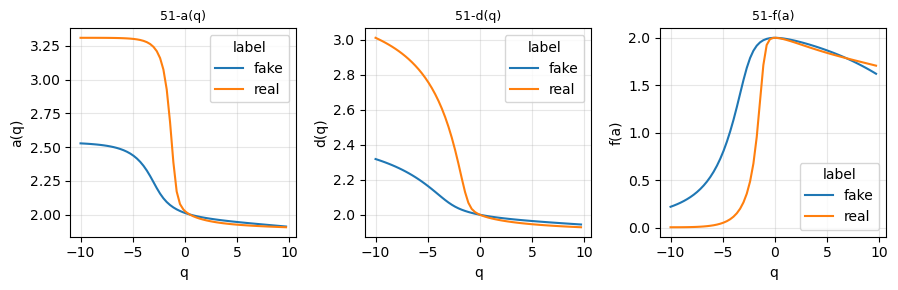

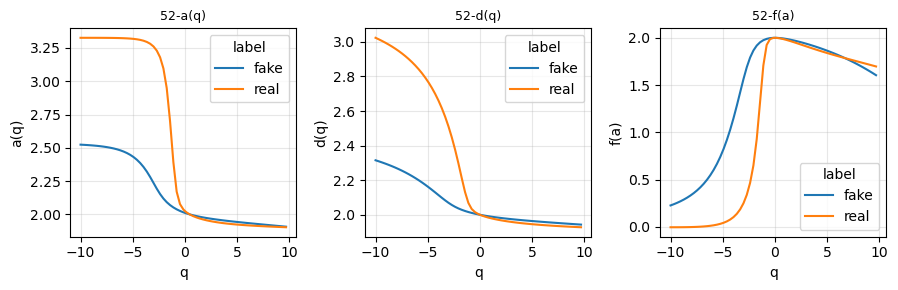

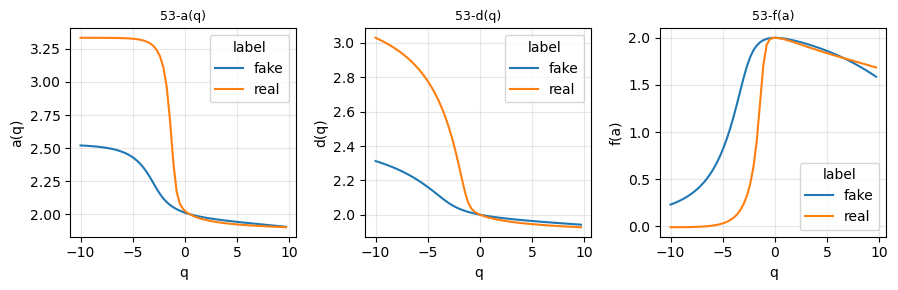

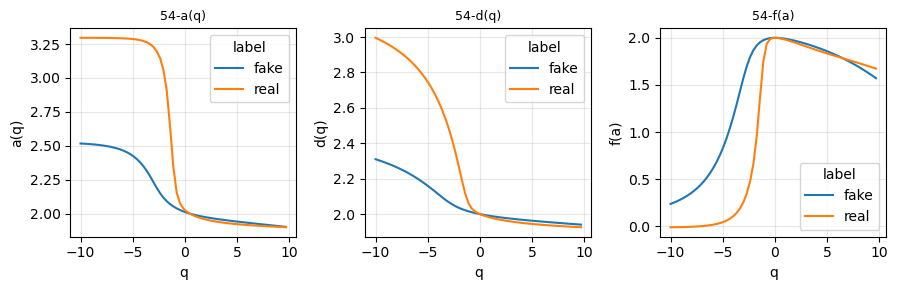

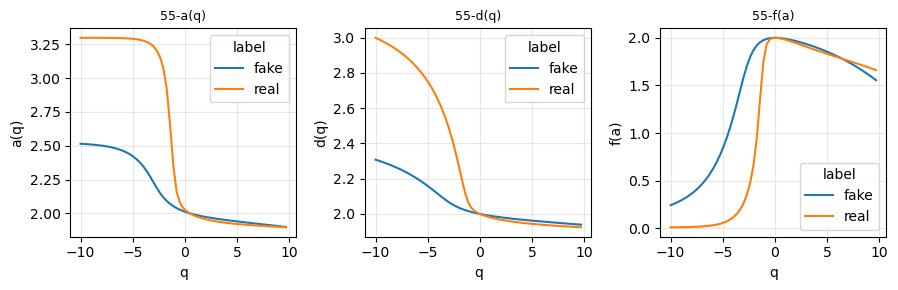

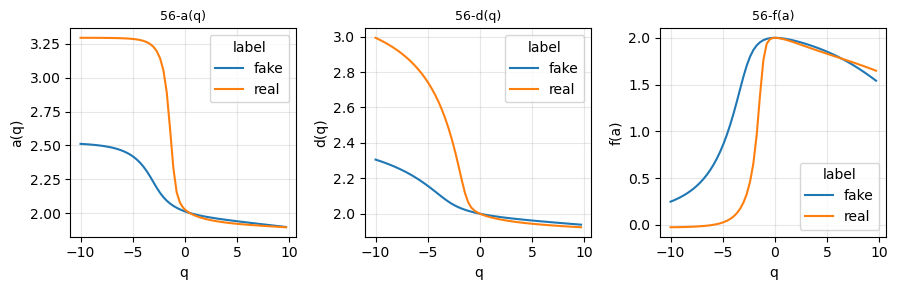

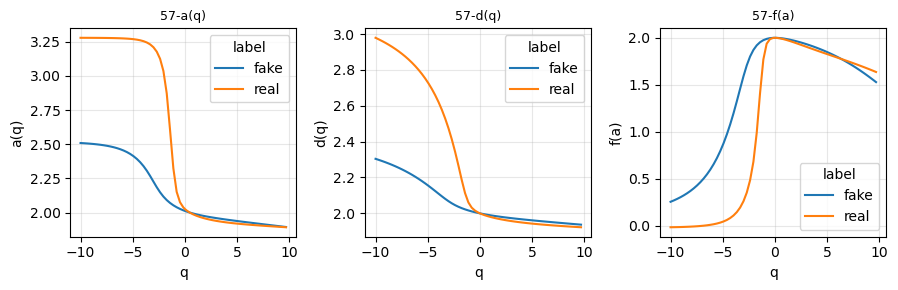

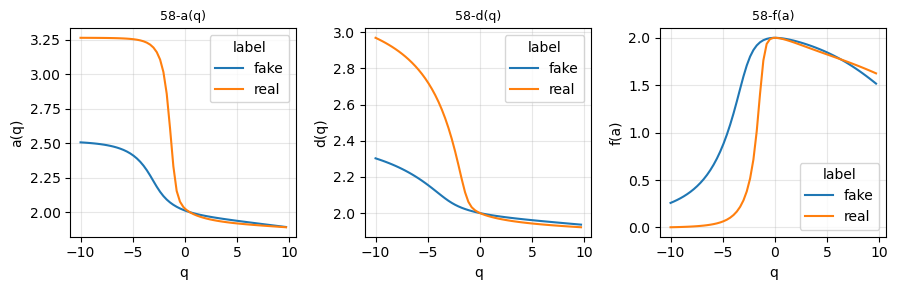

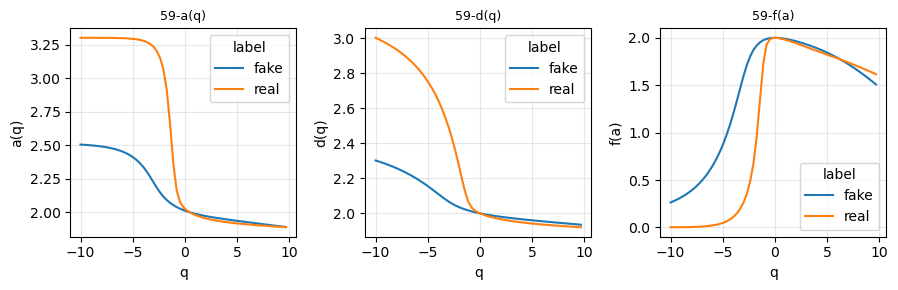

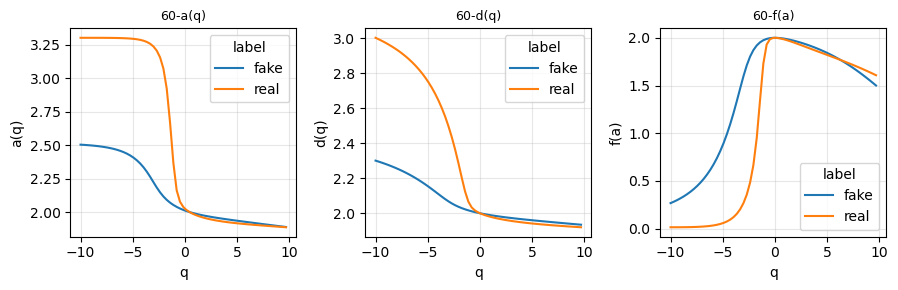

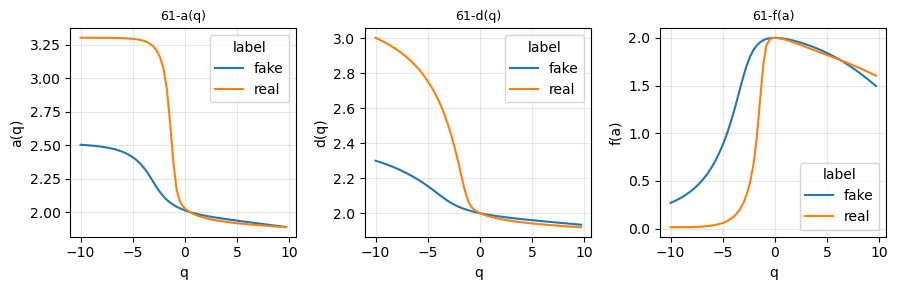

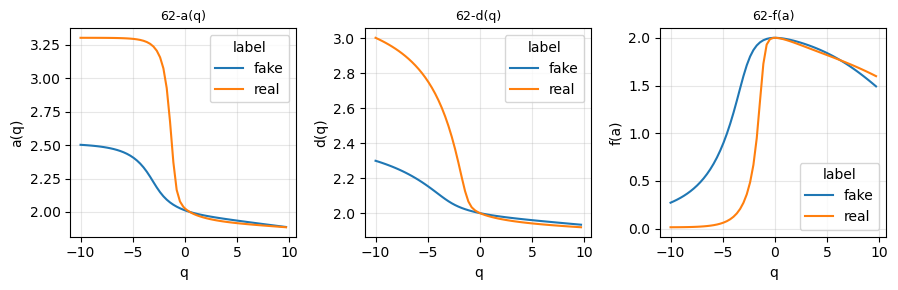

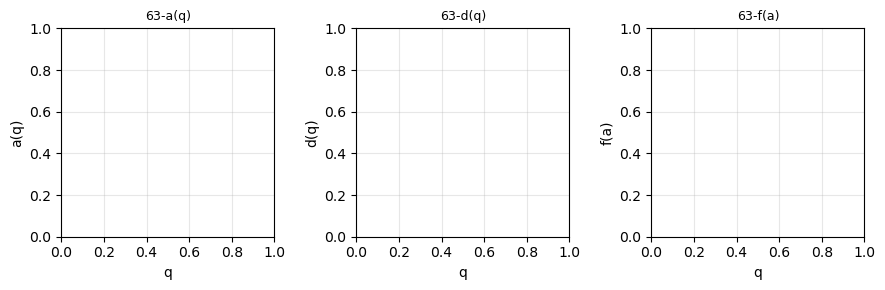

In [13]:
ys = ['a(q)','d(q)','f(a)']
df_tmp = df_data[df_data['img']=='gray']
df_tmp = df_tmp.groupby(["label","n","q"]).mean(numeric_only=True).reset_index()
for i in range(0,64):
    df_t = df_tmp[df_tmp['n'] == i]
    CImageSimilarity.display_plots(df_t,'q',ys,hue='label',title=i)

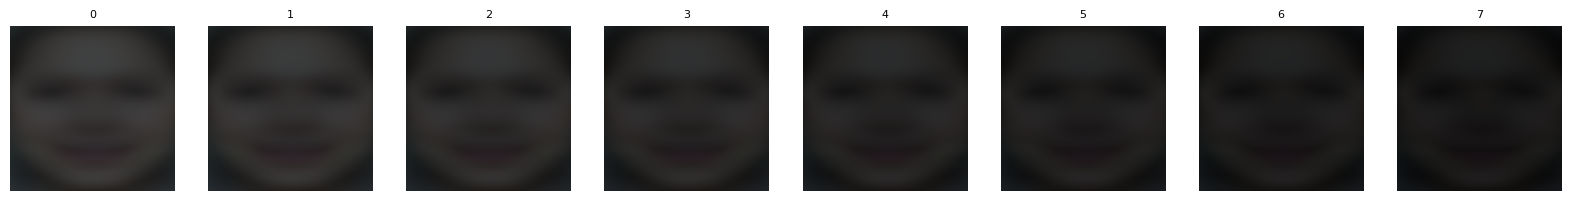

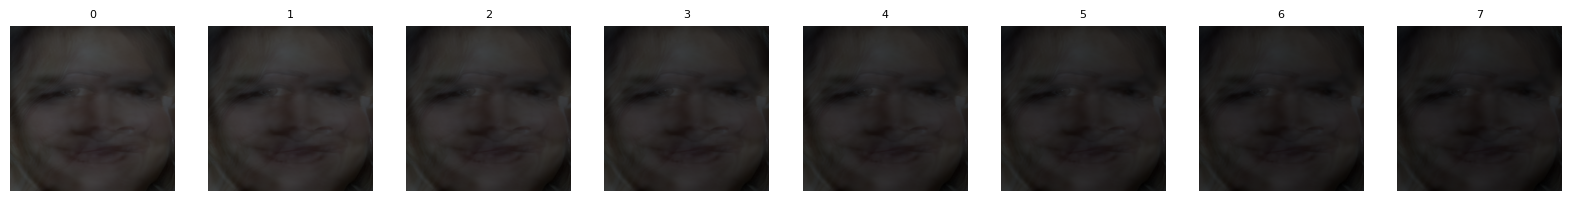

In [14]:
CImageUtils.display(real.get_svd()[32:40])
CImageUtils.display(fake.get_svd()[32:40])